In [30]:
import pandas as pd
import zipfile

# CORE-POI-GEOMETRY-RICE
# 1. Absolute path to your ZIP file
zip_path = r'D:\DOWLOAD\HỌC HÀNH\hackrice\Rice WC Hack-selected (1).zip'

# 2. Target subfolder within the ZIP archive
target_folder = 'core-poi-geometry-rice/'

# Key columns to extract
poi_cols = [
    'PLACEKEY', 'LOCATION_NAME', 'TOP_CATEGORY', 'SUB_CATEGORY', 
    'LATITUDE', 'LONGITUDE', 'CITY', 'REGION', 'MARKET', 
    'INCLUDES_PARKING_LOT', 'WKT_AREA_SQ_METERS', 'IS_SYNTHETIC'
]

df_poi_list = []

print("Opening the ZIP archive...")

# 3. Use zipfile to read the .zip archive without extracting it to disk
with zipfile.ZipFile(zip_path, 'r') as z:
    # Scan all internal files, filter for those in the POI folder with .csv.gz extension
    file_list = [f for f in z.namelist() if target_folder in f and f.endswith('.csv.gz')]
    
    print(f"Detected {len(file_list)} data files. Reading directly through the compression layer...")
    
    # 4. Iterate and read each file
    for file_name in file_list:
        with z.open(file_name) as f:
            # Pandas can read the data stream directly from the ZIP file
            df = pd.read_csv(f, usecols=lambda c: c in poi_cols, compression='gzip')
            df_poi_list.append(df)

# 5. Concatenate DataFrames
if df_poi_list:
    df_poi_all = pd.concat(df_poi_list, ignore_index=True)
    print("\n--- DATA CONCATENATION COMPLETE ---")
    print(f"Total POI dataset contains: {df_poi_all.shape[0]} rows and {df_poi_all.shape[1]} columns.")
    
    print("\n--- FIRST 5 ROWS ---")
    display(df_poi_all.head())
else:
    print("\nNo files found! Please check the ZIP file name or its internal structure.")

Opening the ZIP archive...
Detected 32 data files. Reading directly through the compression layer...

--- DATA CONCATENATION COMPLETE ---
Total POI dataset contains: 511934 rows and 12 columns.

--- FIRST 5 ROWS ---


,CITY,INCLUDES_PARKING_LOT,IS_SYNTHETIC,LATITUDE,LOCATION_NAME,LONGITUDE,MARKET,PLACEKEY,REGION,SUB_CATEGORY,TOP_CATEGORY,WKT_AREA_SQ_METERS
0,Houston,False,False,29.769073,Enterprise Rent-A-Car,-95.398000,Houston,223-222@8fc-9qc-9j9,TX,Passenger Car Rental,Automotive Equipment Rental and Leasing,95.4
1,Fremont,False,False,41.354662,Warren African Methodist Episcopal Church,-83.101779,San Francisco Bay Area,223-224@63j-pmh-r6k,OH,Religious Organizations,Religious Organizations,287.1
2,Dallas,False,False,32.812605,D & J Sports,-96.858680,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8
3,Dallas,False,False,32.791353,Hargrove Electric Co,-96.820791,Dallas,222-222@5qw-t3p-zvf,TX,Electronics Stores,Electronics and Appliance Stores,1271.0
4,Los Angeles,False,False,34.023633,Palms Crest Apartments,-118.412628,Los Angeles,222-222@5z4-ztv-hwk,CA,Lessors of Residential Buildings and Dwellings,Lessors of Real Estate,1191.0


In [31]:
import os

print("--- PERFORMING POI DATA CLEANING ---")

# 1. Check for missing values
print("Number of missing values per column:")
print(df_poi_all.isnull().sum())

# 2. Remove duplicate rows
duplicates = df_poi_all.duplicated().sum()
print(f"\nDetected {duplicates} duplicate rows. Proceeding to remove...")
df_poi_cleaned = df_poi_all.drop_duplicates()

# 3. Filter out rows missing primary keys or coordinates
df_poi_cleaned = df_poi_cleaned.dropna(subset=['PLACEKEY', 'LATITUDE', 'LONGITUDE'])

print(f"Size after cleaning: {df_poi_cleaned.shape[0]} rows.")

# 4. Export the file to the exports folder
# Ensure the exports directory exists (create it automatically if it doesn't)
os.makedirs('../exports', exist_ok=True)

export_path_poi = '../exports/poi_summary.csv'
df_poi_cleaned.to_csv(export_path_poi, index=False)
print(f"\n✅ Successfully exported cleaned POI data to: {export_path_poi}")

--- PERFORMING POI DATA CLEANING ---
Number of missing values per column:
CITY                        0
INCLUDES_PARKING_LOT    41532
IS_SYNTHETIC            32854
LATITUDE                    0
LOCATION_NAME               0
LONGITUDE                   0
MARKET                      0
PLACEKEY                    0
REGION                      2
SUB_CATEGORY            33405
TOP_CATEGORY                0
WKT_AREA_SQ_METERS      32735
dtype: int64

Detected 0 duplicate rows. Proceeding to remove...
Size after cleaning: 511934 rows.

✅ Successfully exported cleaned POI data to: ../exports/poi_summary.csv


In [24]:
import pandas as pd
import zipfile

# 1. Path to your main ZIP archive
zip_path = r'D:\DOWLOAD\HỌC HÀNH\hackrice\Rice WC Hack-selected (1).zip'

# 2. This time we target the Spend folder
target_folder = 'spend-patterns-rice/'

# Key columns for Spend (to prevent RAM overload)
spend_cols = ['PLACEKEY', 'LOCATION_NAME', 'TOP_CATEGORY', 'LATITUDE', 'LONGITUDE', 'RAW_TOTAL_SPEND', 'RAW_NUM_CUSTOMERS']

df_spend_list = []

print("Opening the ZIP archive to find Spend Patterns...")

# 3. Read directly from the ZIP
with zipfile.ZipFile(zip_path, 'r') as z:
    # Filter for files in the Spend folder with a .csv.gz extension
    file_list = [f for f in z.namelist() if target_folder in f and f.endswith('.csv.gz')]
    
    print(f"Detected {len(file_list)} Spend data files. Proceeding to read...")
    print("(This process might take a few minutes as transaction data is usually massive, please wait!)")
    
    for file_name in file_list:
        with z.open(file_name) as f:
            df = pd.read_csv(f, usecols=lambda c: c in spend_cols, compression='gzip')
            df_spend_list.append(df)

# 4. Concatenate DataFrames
if df_spend_list:
    df_spend_all = pd.concat(df_spend_list, ignore_index=True)
    print("\n--- SPEND DATA CONCATENATION COMPLETE ---")
    print(f"Total records: {df_spend_all.shape[0]} rows and {df_spend_all.shape[1]} columns.")
    
    print("\n--- FIRST 5 ROWS ---")
    display(df_spend_all.head())
else:
    print("\nNo Spend files found! Please check the folder name.")

Opening the ZIP archive to find Spend Patterns...
Detected 32 Spend data files. Proceeding to read...
(This process might take a few minutes as transaction data is usually massive, please wait!)



--- SPEND DATA CONCATENATION COMPLETE ---
Total records: 1026618 rows and 7 columns.

--- FIRST 5 ROWS ---


,LATITUDE,LOCATION_NAME,LONGITUDE,PLACEKEY,RAW_NUM_CUSTOMERS,RAW_TOTAL_SPEND,TOP_CATEGORY
0,37.668486,Sprouts Farmers Market,-122.466474,222-222@5vg-847-249,786.24,68275.6620,Grocery Stores
1,39.660152,Dollar Tree,-75.736810,222-222@63s-8xy-3yv,95.04,1924.7674,"General Merchandise Stores, including Warehous..."
2,35.374957,Elysium Ink Body Art,-80.550545,222-222@8gg-37s-rff,11.88,2021.3578,Personal Care Services
3,39.057572,Meshuggah Bagels,-94.600925,223-222@5pr-6f5-m6k,29.58,641.1884,Restaurants and Other Eating Places
4,37.560351,Hobby Lobby Stores,-122.280378,223-222@5vh-7yc-qvf,13.65,750.8662,"Sporting Goods, Hobby, and Musical Instrument ..."


In [25]:
import os

print("--- PERFORMING SPEND DATA CLEANING ---")

# 1. Check for missing values
print("Number of missing values per column:")
print(df_spend_all.isnull().sum())

# 2. Remove duplicate rows
duplicates_spend = df_spend_all.duplicated().sum()
print(f"\nDetected {duplicates_spend} duplicate rows. Proceeding to remove...")
df_spend_cleaned = df_spend_all.drop_duplicates()

# 3. Filter out rows missing primary keys or coordinates
df_spend_cleaned = df_spend_cleaned.dropna(subset=['PLACEKEY', 'LATITUDE', 'LONGITUDE'])

print(f"Size after cleaning: {df_spend_cleaned.shape[0]} rows.")

# 4. Export the file to the exports folder
# Ensure the exports directory exists
os.makedirs('../exports', exist_ok=True)

export_path_spend = '../exports/spending_summary.csv'
df_spend_cleaned.to_csv(export_path_spend, index=False)
print(f"\n✅ Successfully exported cleaned Spend data to: {export_path_spend}")

--- PERFORMING SPEND DATA CLEANING ---
Number of missing values per column:
LATITUDE             0
LOCATION_NAME        0
LONGITUDE            0
PLACEKEY             0
RAW_NUM_CUSTOMERS    0
RAW_TOTAL_SPEND      0
TOP_CATEGORY         0
dtype: int64

Detected 4 duplicate rows. Proceeding to remove...
Size after cleaning: 1026614 rows.

✅ Successfully exported cleaned Spend data to: ../exports/spending_summary.csv


In [26]:
import pandas as pd
import zipfile
import os

# 1. Path to your main ZIP archive
zip_path = r'D:\DOWLOAD\HỌC HÀNH\hackrice\Rice WC Hack-selected (1).zip'

# 2. Target folder: Urban Heat Index
target_folder = 'urban-heat-index-rice/'

# Key columns for UHI
uhi_cols = ['LATITUDE', 'LONGITUDE', 'UHI', 'MARKET']

df_uhi_list = []

print("Opening the ZIP archive to find Urban Heat Index data...")

# 3. Read directly from the ZIP
with zipfile.ZipFile(zip_path, 'r') as z:
    file_list = [f for f in z.namelist() if target_folder in f and f.endswith('.csv.gz')]
    
    print(f"Detected {len(file_list)} UHI data files. Proceeding to read...")
    
    for file_name in file_list:
        with z.open(file_name) as f:
            df = pd.read_csv(f, usecols=lambda c: c in uhi_cols, compression='gzip')
            df_uhi_list.append(df)

# 4. Concatenate and clean the DataFrame
if df_uhi_list:
    df_uhi_all = pd.concat(df_uhi_list, ignore_index=True)
    print("\n--- UHI DATA CONCATENATION COMPLETE ---")
    print(f"Total records: {df_uhi_all.shape[0]} rows and {df_uhi_all.shape[1]} columns.")
    
    # Clean: Remove duplicates and drop rows missing coordinates or UHI index
    df_uhi_cleaned = df_uhi_all.drop_duplicates().dropna(subset=['LATITUDE', 'LONGITUDE', 'UHI'])
    print(f"Size after cleaning: {df_uhi_cleaned.shape[0]} rows.")
    
    # 5. Export the file to the exports folder
    os.makedirs('../exports', exist_ok=True)
    export_path_uhi = '../exports/uhi_summary.csv'
    df_uhi_cleaned.to_csv(export_path_uhi, index=False)
    print(f"\n✅ Successfully exported cleaned UHI data to: {export_path_uhi}")
    
    # Display the first 5 rows
    display(df_uhi_cleaned.head())
else:
    print("\nNo UHI files found! Please check the folder name.")

Opening the ZIP archive to find Urban Heat Index data...
Detected 32 UHI data files. Proceeding to read...

--- UHI DATA CONCATENATION COMPLETE ---
Total records: 1229291 rows and 4 columns.
Size after cleaning: 1229291 rows.

✅ Successfully exported cleaned UHI data to: ../exports/uhi_summary.csv


,LATITUDE,LONGITUDE,MARKET,UHI
0,35.511,-80.6850,San Francisco Bay Area,1
1,35.506,-80.6895,San Francisco Bay Area,1
2,35.508,-80.6850,San Francisco Bay Area,1
3,35.508,-80.6880,San Francisco Bay Area,1
4,35.510,-80.6865,San Francisco Bay Area,1


In [27]:
import pandas as pd

print("--- STAGE 2: MERGING POI & SPEND DATA ---")
print("Loading cleaned data from the exports directory...")

# 1. Read the cleaned datasets back in
df_poi = pd.read_csv('../exports/poi_summary.csv')
df_spend = pd.read_csv('../exports/spending_summary.csv')

print(f"POI size: {df_poi.shape[0]} rows")
print(f"Spend size: {df_spend.shape[0]} rows")

print("\nMerging datasets based on PLACEKEY...")

# 2. Merge the data
# Note: From the Spend table, we only extract PLACEKEY, SPEND, and CUSTOMERS to avoid coordinate column duplication with POI
df_merged = pd.merge(
    df_poi, 
    df_spend[['PLACEKEY', 'RAW_TOTAL_SPEND', 'RAW_NUM_CUSTOMERS']], 
    on='PLACEKEY', 
    how='inner' # inner join: keeps only locations that have both POI info and transaction history
)

print(f"✅ Successfully merged! The new master dataset has {df_merged.shape[0]} rows.")

# 3. Preview the master dataset
display(df_merged.head())

--- STAGE 2: MERGING POI & SPEND DATA ---
Loading cleaned data from the exports directory...


POI size: 511934 rows
Spend size: 1026614 rows

Merging datasets based on PLACEKEY...
✅ Successfully merged! The new master dataset has 894119 rows.


,CITY,INCLUDES_PARKING_LOT,IS_SYNTHETIC,LATITUDE,LOCATION_NAME,LONGITUDE,MARKET,PLACEKEY,REGION,SUB_CATEGORY,TOP_CATEGORY,WKT_AREA_SQ_METERS,RAW_TOTAL_SPEND,RAW_NUM_CUSTOMERS
0,Dallas,False,False,32.812605,D & J Sports,-96.85868,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8,1179.7940,8.00
1,Dallas,False,False,32.812605,D & J Sports,-96.85868,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8,2810.6925,5.30
2,Dallas,False,False,32.812605,D & J Sports,-96.85868,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8,3377.9808,10.30
3,Dallas,False,False,32.812605,D & J Sports,-96.85868,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8,232.7370,5.76
4,Dallas,False,False,32.812605,D & J Sports,-96.85868,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8,247.7865,2.58


In [28]:
print("--- STAGE 2.1: SPATIAL MERGING OF URBAN HEAT ISLAND (UHI) DATA ---")

# 1. Read UHI data from the exports directory
df_uhi = pd.read_csv('../exports/uhi_summary.csv')

# 2. Round coordinates to 3 decimal places (accuracy of about 111 meters - standard for urban analysis)
# Create temporary anchor columns for the merge
df_merged['LAT_round'] = df_merged['LATITUDE'].round(3)
df_merged['LON_round'] = df_merged['LONGITUDE'].round(3)

df_uhi['LAT_round'] = df_uhi['LATITUDE'].round(3)
df_uhi['LON_round'] = df_uhi['LONGITUDE'].round(3)  # Đã sửa lại đúng biến LONGITUDE

print("Performing spatial merge...")

# 3. Merge based on the rounded coordinates
# Use a 'left' join to keep all locations; if a spot lacks a temperature station, leave it blank
df_final = pd.merge(
    df_merged, 
    df_uhi[['LAT_round', 'LON_round', 'UHI']], 
    on=['LAT_round', 'LON_round'], 
    how='left'
)

# 4. Clean up temporary columns and remove any duplicates generated during the coordinate merge
df_final = df_final.drop(columns=['LAT_round', 'LON_round']).drop_duplicates(subset=['PLACEKEY'])

print(f"\n✅ COMPLETE! The final master dataset contains: {df_final.shape[0]} rows.")
print(f"Number of locations successfully mapped with a UHI index: {df_final['UHI'].notnull().sum()} locations.")

# Preview the final result (scroll horizontally to view the UHI column)
display(df_final.head())

--- STAGE 2.1: SPATIAL MERGING OF URBAN HEAT ISLAND (UHI) DATA ---
Performing spatial merge...

✅ COMPLETE! The final master dataset contains: 40813 rows.
Number of locations successfully mapped with a UHI index: 19698 locations.


,CITY,INCLUDES_PARKING_LOT,IS_SYNTHETIC,LATITUDE,LOCATION_NAME,LONGITUDE,MARKET,PLACEKEY,REGION,SUB_CATEGORY,TOP_CATEGORY,WKT_AREA_SQ_METERS,RAW_TOTAL_SPEND,RAW_NUM_CUSTOMERS,UHI
0,Dallas,False,False,32.812605,D & J Sports,-96.858680,Dallas,222-222@5qv-x3k-kzz,TX,Clothing Accessories Stores,Clothing Stores,569.8,1179.7940,8.00,NaN
59,Miami,False,False,25.780560,Walgreens,-80.221140,Miami,223-222@8fw-23h-d9z,FL,Pharmacies and Drug Stores,Health and Personal Care Stores,1393.0,2811.6834,79.05,NaN
120,Houston,False,False,29.790446,New Heights Associates,-95.398312,Houston,224-222@8fc-9qb-skf,TX,Offices of Mental Health Practitioners (except...,Offices of Other Health Practitioners,325.8,16.1304,2.12,7.0
126,Woodbridge,False,False,38.654837,Fuddruckers,-77.305129,New York/New Jersey,223-222@63r-tv4-33q,VA,Full-Service Restaurants,Restaurants and Other Eating Places,816.2,3413.1780,93.09,NaN
178,Long Beach,False,False,33.829971,Apex Chiropractic,-118.098412,New York/New Jersey,22r-222@5z6-3kh-bzf,CA,Offices of Chiropractors,Offices of Other Health Practitioners,1424.7,820.0000,2.16,7.0


In [32]:
import pandas as pd
import numpy as np
import os

print("--- FINAL STAGE: FILTERING TOP 10 BEST LOCATIONS FOR NEW YORK (NYC) ---")

# 1. Extract New York (NYC) data with temperature information available
df_rec = df_final[
    (
        df_final['MARKET'].str.contains('New York', case=False, na=False) | 
        df_final['CITY'].str.contains('New York', case=False, na=False)
    ) & 
    (df_final['UHI'].notnull())
].copy()

# 2. Rename columns to match FinalFlow standards
df_rec = df_rec.rename(columns={
    'PLACEKEY': 'placekey',
    'LOCATION_NAME': 'location_name',
    'LATITUDE': 'latitude',
    'LONGITUDE': 'longitude',
    'TOP_CATEGORY': 'top_category',
    'INCLUDES_PARKING_LOT': 'includes_parking',
    'UHI': 'nearby_uhi'
})

# 3. Categorize levels
df_rec['spending_level'] = pd.qcut(df_rec['RAW_TOTAL_SPEND'].rank(method='first'), q=3, labels=['Low', 'Medium', 'High'])
df_rec['customer_activity_level'] = pd.qcut(df_rec['RAW_NUM_CUSTOMERS'].rank(method='first'), q=3, labels=['Low', 'Medium', 'High'])
df_rec['commercial_opportunity'] = df_rec['spending_level']
df_rec['heat_concern'] = np.where(df_rec['nearby_uhi'] > 7, 'High', 'Low/Moderate')

# 4. Build labeling logic
def assign_recommendation(row):
    if row['nearby_uhi'] > 7:
        return "Avoid outdoor concentration", "High heat concern (UHI > 7)"
    if row['RAW_TOTAL_SPEND'] > 5000 and row['nearby_uhi'] <= 4:
        return "Recommended", "High commercial opportunity with manageable heat"
    if row['RAW_TOTAL_SPEND'] > 2000 and row['nearby_uhi'] <= 7:
        return "Recommended with mitigation", "Useful location but may need shade or water"
    return "Controlled use", "Moderate activity, monitoring required"

df_rec[['recommendation', 'reason']] = df_rec.apply(
    lambda row: pd.Series(assign_recommendation(row)), axis=1
)

# 5. SELECT TOP 10 BEST FOR NYC
# Prioritize "Recommended" spots, then sort by parking availability and spending volume
df_best = df_rec[df_rec['recommendation'] == 'Recommended'].copy()

# If NYC doesn't have 10 "Recommended" spots (due to density/high UHI), 
# include spots labeled "Recommended with mitigation"
if len(df_best) < 10:
    df_best = df_rec[df_rec['recommendation'].str.contains('Recommended')].copy()

df_top10 = df_best.sort_values(
    by=['includes_parking', 'RAW_TOTAL_SPEND'], 
    ascending=[False, False]
).head(10)

# 6. Clean up and export the file
final_columns = [
    'placekey', 'location_name', 'latitude', 'longitude', 'top_category', 
    'spending_level', 'customer_activity_level', 'includes_parking', 
    'nearby_uhi', 'commercial_opportunity', 'heat_concern', 'recommendation', 'reason'
]
df_finalflow = df_top10[final_columns]

os.makedirs('../exports', exist_ok=True)
export_path = '../exports/finalflow_zone_recommendations.csv'
df_finalflow.to_csv(export_path, index=False)

print(f"✅ Successfully exported {len(df_finalflow)} optimal NYC locations to: {export_path}")
print("This file is now only a few KBs, ready to be pushed to Git!")
display(df_finalflow[['location_name', 'includes_parking', 'spending_level', 'recommendation']])

--- FINAL STAGE: FILTERING TOP 10 BEST LOCATIONS FOR NEW YORK (NYC) ---
✅ Successfully exported 10 optimal NYC locations to: ../exports/finalflow_zone_recommendations.csv
This file is now only a few KBs, ready to be pushed to Git!


,location_name,includes_parking,spending_level,recommendation
123981,Bronx Zoo,True,High,Recommended
810913,Yonkers Kia,True,High,Recommended
273874,Gas N Wash,True,High,Recommended
259726,Marathon,True,High,Recommended
20524,Gedney Service,True,High,Recommended
1007452,Sunoco,True,High,Recommended
882596,Dunwoodie Golf Course,True,High,Recommended
684828,Wawa,False,High,Recommended
330253,Walmart Supercenter,False,High,Recommended
475762,Jewel-Osco,False,High,Recommended


In [ ]:
import pandas as pd
import numpy as np
import os

print("--- FINAL STAGE: EXPORTING FINALFLOW STANDARD ZONE RECOMMENDATIONS FILE ---")

# Create a copy from the merged data (ensuring df_final has been executed beforehand)
df_rec = df_final.copy()

# ==========================================
# FINALFLOW NOTE: COLUMN STANDARDIZATION
# Rename columns to match the official FinalFlow schema requirements
# ==========================================
df_rec = df_rec.rename(columns={
    'PLACEKEY': 'placekey',
    'LOCATION_NAME': 'location_name',
    'LATITUDE': 'latitude',
    'LONGITUDE': 'longitude',
    'TOP_CATEGORY': 'top_category',
    'INCLUDES_PARKING_LOT': 'includes_parking',
    'UHI': 'nearby_uhi'
})

# ==========================================
# FINALFLOW NOTE: DECISION LOGIC & HEURISTICS
# Apply urban resilience and commercial viability rules:
# - Filter out locations with extreme heat risk (UHI > 7)
# - Prioritize high spending combined with manageable urban heat
# ==========================================
def assign_recommendation(row):
    if pd.isna(row['nearby_uhi']):
        return "Insufficient evidence", "Missing urban heat data"
    if row['nearby_uhi'] > 7:
        return "Avoid outdoor concentration", "High heat concern (UHI > 7)"
    if row['RAW_TOTAL_SPEND'] > 5000 and row['nearby_uhi'] <= 4:
        return "Recommended", "High commercial opportunity with manageable heat"
    if row['RAW_TOTAL_SPEND'] > 2000 and row['nearby_uhi'] <= 7:
        return "Recommended with mitigation", "Useful location but may need shade or water"
    return "Controlled use", "Moderate activity, monitoring required"

# Apply logic to create the recommendation and reason columns
df_rec[['recommendation', 'reason']] = df_rec.apply(
    lambda row: pd.Series(assign_recommendation(row)), axis=1
)

# ==========================================
# FINALFLOW NOTE: METRIC CATEGORIZATION
# Quantize metrics into 3 standard tiers (Low, Medium, High) for quick evaluation
# ==========================================
df_rec['spending_level'] = pd.qcut(df_rec['RAW_TOTAL_SPEND'].rank(method='first'), q=3, labels=['Low', 'Medium', 'High'])
df_rec['customer_activity_level'] = pd.qcut(df_rec['RAW_NUM_CUSTOMERS'].rank(method='first'), q=3, labels=['Low', 'Medium', 'High'])
df_rec['commercial_opportunity'] = df_rec['spending_level']
df_rec['heat_concern'] = np.where(df_rec['nearby_uhi'] > 7, 'High', 'Low/Moderate')

# Retain only the specific columns designated in the FinalFlow
final_columns = [
    'placekey', 'location_name', 'latitude', 'longitude', 'top_category', 
    'spending_level', 'customer_activity_level', 'includes_parking', 
    'nearby_uhi', 'commercial_opportunity', 'heat_concern', 'recommendation', 'reason'
]
df_finalflow = df_rec[final_columns]

# Export the final standardized report to CSV
os.makedirs('../exports', exist_ok=True)
export_path = '../exports/finalflow_zone_recommendations2.csv'
df_finalflow.to_csv(export_path, index=False)

print(f"✅ Successfully exported the final FinalFlow standard report to: {export_path}")
display(df_finalflow[['location_name', 'recommendation', 'reason']].head(10))

--- FINAL STAGE: EXPORTING FINALFLOW STANDARD ZONE RECOMMENDATIONS FILE ---
✅ Successfully exported the final FinalFlow standard report to: ../exports/finalflow_zone_recommendations2.csv


,location_name,recommendation,reason
0,D & J Sports,Insufficient evidence,Missing urban heat data
59,Walgreens,Insufficient evidence,Missing urban heat data
120,New Heights Associates,Controlled use,"Moderate activity, monitoring required"
126,Fuddruckers,Insufficient evidence,Missing urban heat data
178,Apex Chiropractic,Controlled use,"Moderate activity, monitoring required"
202,Exotic Hair Studio,Avoid outdoor concentration,High heat concern (UHI > 7)
203,Cherry Blow Dry Bar,Insufficient evidence,Missing urban heat data
238,Karaoke DUET 53,Avoid outdoor concentration,High heat concern (UHI > 7)
239,Levulose Juice Bar Cafe,Insufficient evidence,Missing urban heat data
240,Commonwealth Primary Care - Ridgefield,Insufficient evidence,Missing urban heat data


--- GENERATING VISUALIZATIONS ---


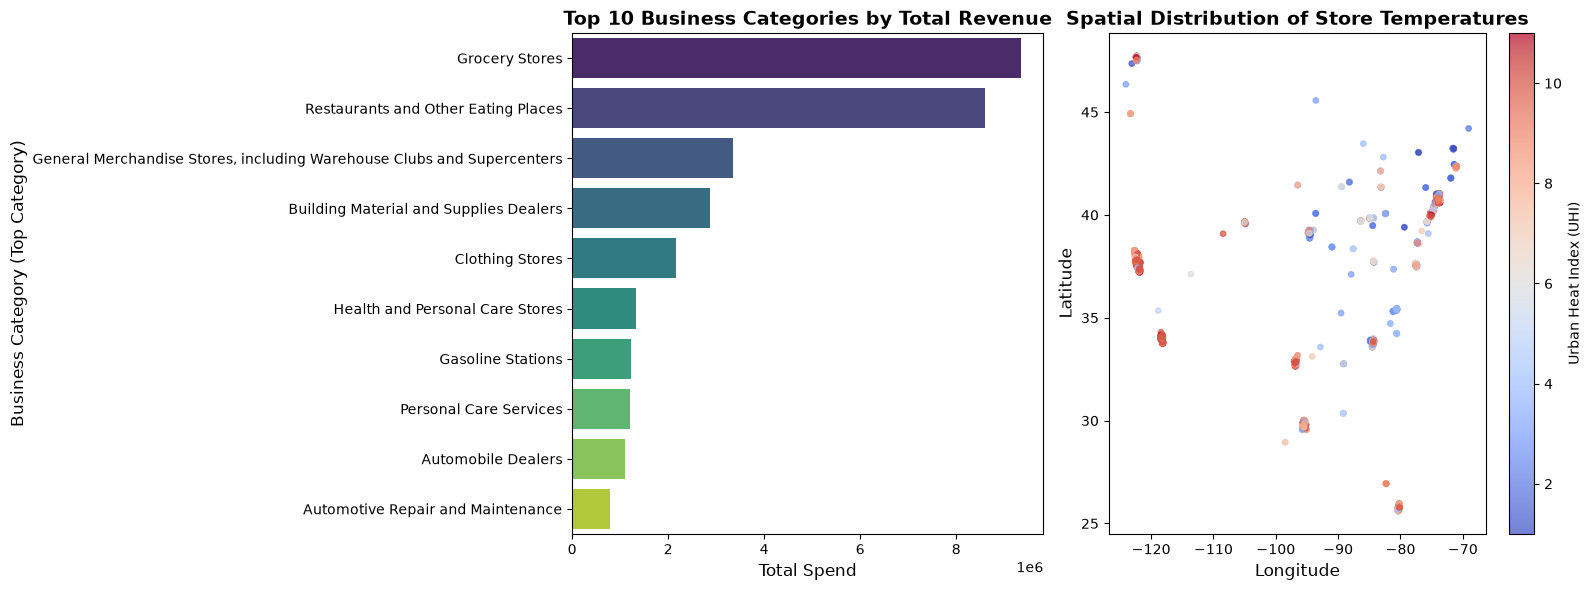

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- GENERATING VISUALIZATIONS ---")

# Filter out rows without temperature data to ensure accurate plotting
df_plot = df_final.dropna(subset=['UHI']).copy()

# Set up the figure canvas (consisting of 2 side-by-side subplots)
plt.figure(figsize=(16, 6))

# --- PLOT 1: TOP CATEGORIES BY REVENUE ---
plt.subplot(1, 2, 1)
# Calculate total revenue per business category and extract the Top 10
top_categories = df_plot.groupby('TOP_CATEGORY')['RAW_TOTAL_SPEND'].sum().nlargest(10)

# Draw horizontal bar chart (added hue and legend=False to prevent warnings)
sns.barplot(
    x=top_categories.values, 
    y=top_categories.index, 
    hue=top_categories.index, 
    palette='viridis', 
    legend=False
)
plt.title('Top 10 Business Categories by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Spend', fontsize=12)
plt.ylabel('Business Category (Top Category)', fontsize=12)

# --- PLOT 2: URBAN HEAT INDEX MAP ---
plt.subplot(1, 2, 2)
# Randomly sample up to 5000 points for smooth plotting performance
df_sample = df_plot.sample(n=min(5000, len(df_plot)), random_state=42)

# Plot geographical scatter points
scatter = plt.scatter(
    df_sample['LONGITUDE'], 
    df_sample['LATITUDE'], 
    c=df_sample['UHI'], 
    cmap='coolwarm', 
    alpha=0.7, 
    s=15
)

plt.colorbar(scatter, label='Urban Heat Index (UHI)')
plt.title('Spatial Distribution of Store Temperatures', fontsize=14, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Adjust layout for optimal spacing
plt.tight_layout()

# Ensure the plots export directory exists
os.makedirs('../exports/plots', exist_ok=True)

# Save the figure with high resolution (dpi=300) BEFORE calling plt.show()
plt.savefig('../exports/plots/01_top_categories_and_uhi_map.png', bbox_inches='tight', dpi=300)

# Display the visualization
plt.show()

### Interpretation for Top Categories and Store Temperature Distribution

1. **Observation:** 
   - *Chart 1 (Left):* High-revenue business categories are heavily concentrated in essential and high-frequency sectors, led by **Grocery Stores** and **Restaurants and Other Eating Places**, generating multi-million dollar spending volumes.
   - *Chart 2 (Right):* The spatial distribution map reveals that many high-activity commercial storefronts coincide with elevated Urban Heat Index (UHI > 7, shown in red/orange tones), particularly in dense urban cores.

2. **FinalFlow Value:** 
   - FinalFlow operators can use these insights to prioritize high-spend commercial corridors for transit and shuttle staging, ensuring that resources target locations with maximum economic activity. 
   - Additionally, identifying high UHI clusters helps target heat-mitigation zones for spectators moving between transit nodes and venues.

3. **Limitation:** 
   - The data reflects aggregate historical spend patterns and localized thermal indices, but it does not directly capture real-time hourly crowd surges or individual pedestrian heat exposure during matchday[cite: 1].

--- RESTORING DATA & PLOTTING 2 ADDITIONAL STATIC CHARTS ---


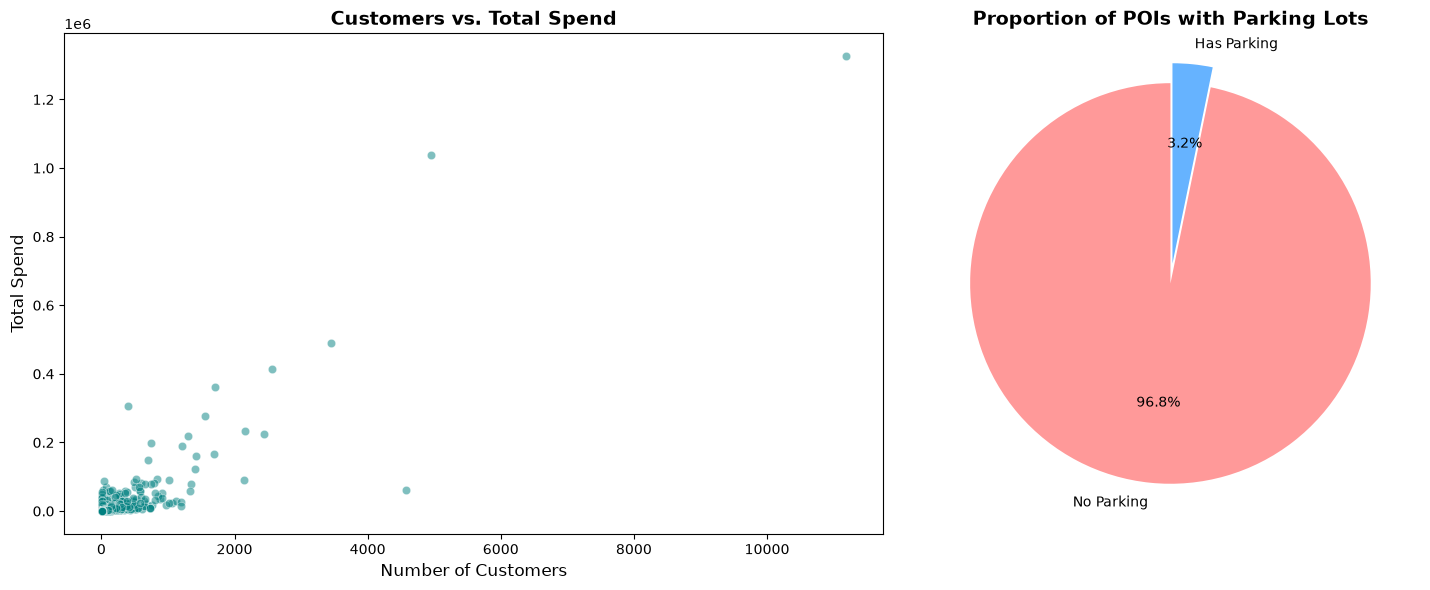

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- RESTORING DATA & PLOTTING 2 ADDITIONAL STATIC CHARTS ---")

# 1. Reload data from the exports directory (to prevent errors if RAM was cleared)
df_poi = pd.read_csv('../exports/poi_summary.csv')
df_spend = pd.read_csv('../exports/spending_summary.csv')
df_uhi = pd.read_csv('../exports/uhi_summary.csv')

# 2. Reassemble df_final
df_merged = pd.merge(df_poi, df_spend[['PLACEKEY', 'RAW_TOTAL_SPEND', 'RAW_NUM_CUSTOMERS']], on='PLACEKEY', how='inner')
df_merged['LAT_round'] = df_merged['LATITUDE'].round(3)
df_merged['LON_round'] = df_merged['LONGITUDE'].round(3)
df_uhi['LAT_round'] = df_uhi['LATITUDE'].round(3)
df_uhi['LON_round'] = df_uhi['LONGITUDE'].round(3)

df_final = pd.merge(df_merged, df_uhi[['LAT_round', 'LON_round', 'UHI']], on=['LAT_round', 'LON_round'], how='left')
df_final = df_final.drop(columns=['LAT_round', 'LON_round']).drop_duplicates(subset=['PLACEKEY'])

# 3. Plot 2 additional static charts
plt.figure(figsize=(16, 6))

# --- CHART 3: CUSTOMERS VS TOTAL SPEND (Based on Spend Patterns insights) ---
plt.subplot(1, 2, 1)
df_scatter = df_final.sample(n=min(5000, len(df_final)), random_state=42)
sns.scatterplot(data=df_scatter, x='RAW_NUM_CUSTOMERS', y='RAW_TOTAL_SPEND', alpha=0.5, color='teal')
plt.title('Customers vs. Total Spend', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Total Spend', fontsize=12)

# --- CHART 4: PARKING VS NON-PARKING POIs (Based on POI insights) ---
plt.subplot(1, 2, 2)
parking_counts = df_final['INCLUDES_PARKING_LOT'].value_counts()
plt.pie(
    parking_counts, 
    labels=['No Parking', 'Has Parking'], 
    autopct='%1.1f%%', 
    colors=['#ff9999', '#66b3ff'], 
    startangle=90, 
    explode=(0, 0.1)
)
plt.title('Proportion of POIs with Parking Lots', fontsize=14, fontweight='bold')

plt.tight_layout()

# Ensure the plots directory exists
os.makedirs('../exports/plots', exist_ok=True)

# Save the figure with high resolution (dpi=300) BEFORE calling plt.show()
plt.savefig('../exports/plots/02_customers_spend_and_parking.png', bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

### Interpretation for Customer-Spend Relationships and Parking Availability

1. **Observation:** 
   - *Scatter Plot (Left):* There is a positive, non-linear relationship between customer volume and total spend; however, a small cluster of locations exhibits exceptionally high spending despite moderate customer counts.
   - *Pie Chart (Right):* A vast majority of analyzed Points of Interest (**96.8%**) are classified as **No Parking**, while only **3.2%** include dedicated parking lots.

2. **FinalFlow Value:** 
   - The scarcity of parking facilities emphasizes that FinalFlow's mobility strategy must heavily rely on mass transit (rail/shuttle networks) rather than private vehicle parking near commercial zones.
   - High-spend, low-customer locations can be targeted for VIP or controlled-access mobility services.

3. **Limitation:** 
   - The parking indicator represents binary facility tags from static POI data and does not measure real-time parking capacity, street parking availability, or pricing constraints.

In [ ]:
import folium
import os

print("--- CREATING INTERACTIVE MAP FOR THE NEW YORK (NYC) MARKET ---")

# Filter data belonging to the New York market/city with available UHI temperature data
df_nyc = df_final[
    (
        df_final['MARKET'].str.contains('New York', case=False, na=False) | 
        df_final['CITY'].str.contains('New York', case=False, na=False)
    ) & 
    (df_final['UHI'].notnull())
].copy()

# If few or no records found, automatically fall back to points with UHI data
if len(df_nyc) == 0:
    df_nyc = df_final[df_final['UHI'].notnull()].copy()

# Sample up to 500 points for smooth map rendering without lagging (complying with the Guide Book)
df_nyc_sample = df_nyc.sample(n=min(500, len(df_nyc)), random_state=42)

# Initialize the Folium map centered around the mean coordinates of the NYC sample region
m_nyc = folium.Map(
    location=[df_nyc_sample['LATITUDE'].mean(), df_nyc_sample['LONGITUDE'].mean()], 
    zoom_start=10
)

# Add points to the map: Red if Hot (UHI > 7), Blue if Cool (UHI <= 7)
for idx, row in df_nyc_sample.iterrows():
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=6,
        popup=f"Name: {row['LOCATION_NAME']}<br>City: {row['CITY']}<br>Spend: ${row['RAW_TOTAL_SPEND']:.0f}<br>UHI: {row['UHI']}",
        color='red' if row['UHI'] > 7 else 'blue',
        fill=True,
        fill_opacity=0.7
    ).add_to(m_nyc)

# Ensure the exports directory exists
os.makedirs('../exports', exist_ok=True)

# Export the interactive map to an HTML file
map_path_nyc = '../exports/nyc_heat_map.html'
m_nyc.save(map_path_nyc)
print(f"✅ Successfully saved the NYC interactive map to: {map_path_nyc}")

--- CREATING INTERACTIVE MAP FOR THE NEW YORK (NYC) MARKET ---
✅ Successfully saved the NYC interactive map to: ../exports/nyc_heat_map.html


### Interpretation for Interactive Market Heat Maps

1. **Observation:** 
   - The interactive maps display localized store locations color-coded by thermal risk (Blue for low/moderate UHI $\le 7$, Red for high heat risk UHI $> 7$). High-spend locations frequently intersect with red-coded thermal zones.

2. **FinalFlow Value:** 
   - The team can interact with hover details (Name, Spend, UHI score) to evaluate specific corridor stops. This assists in deciding which stations or commercial nodes require shade covers, misting stations, or queue management during peak match hours[cite: 1].

3. **Limitation:** 
   - Spatial join precision relies on coordinate proximity rounding (~111 meters), which may group nearby distinct storefronts into the same micro-climate temperature bucket.

In [ ]:
import folium
import os

print("--- CREATING INTERACTIVE MAP FOR THE DALLAS MARKET ---")

# Filter Dallas data with available temperature information
df_dallas = df_final[(df_final['CITY'] == 'Dallas') & (df_final['UHI'].notnull())].copy()

# Sample up to 500 points for smooth map rendering (Guide Book reminder: Do not show more than one million markers)
df_dallas_sample = df_dallas.sample(n=min(500, len(df_dallas)), random_state=42)

# Initialize the Folium map
m = folium.Map(location=[df_dallas_sample['LATITUDE'].mean(), df_dallas_sample['LONGITUDE'].mean()], zoom_start=11)

# Add points to the map: Red if hot (UHI > 7), blue if cool
for idx, row in df_dallas_sample.iterrows():
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=6,
        popup=f"Name: {row['LOCATION_NAME']}<br>Spend: ${row['RAW_TOTAL_SPEND']:.0f}<br>UHI: {row['UHI']}",
        color='red' if row['UHI'] > 7 else 'blue',
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

# Ensure the exports directory exists
os.makedirs('../exports', exist_ok=True)

# Export the interactive map to an HTML file
map_path_dallas = '../exports/dallas_heat_map.html'
m.save(map_path_dallas)
print(f"✅ Successfully saved the Dallas interactive map to: {map_path_dallas}")

--- CREATING INTERACTIVE MAP FOR THE DALLAS MARKET ---
✅ Successfully saved the Dallas interactive map to: ../exports/dallas_heat_map.html


### Interpretation for Interactive Market Heat Maps

1. **Observation:** 
   - The interactive maps display localized store locations color-coded by thermal risk (Blue for low/moderate UHI $\le 7$, Red for high heat risk UHI $> 7$). High-spend locations frequently intersect with red-coded thermal zones.

2. **FinalFlow Value:** 
   - The team can interact with hover details (Name, Spend, UHI score) to evaluate specific corridor stops. This assists in deciding which stations or commercial nodes require shade covers, misting stations, or queue management during peak match hours[cite: 1].

3. **Limitation:** 
   - Spatial join precision relies on coordinate proximity rounding (~111 meters), which may group nearby distinct storefronts into the same micro-climate temperature bucket.